In [70]:
import os
import warnings
import networkx as nx
import numpy    as np
import pandas   as pd
import seaborn  as sns

import plotly.express as px
import matplotlib.pyplot as plt

In [3]:
import matplotlib.pyplot as plt

In [34]:
from itertools import combinations

In [11]:
from scipy import stats
from scipy.stats import kruskal
from scipy.stats import anderson 

In [6]:
df_community_0 = pd.read_csv("../data/communities/by_color/df_community_0.csv")
df_community_1 = pd.read_csv("../data/communities/by_color/df_community_1.csv")
df_community_2 = pd.read_csv("../data/communities/by_color/df_community_2.csv")
df_community_3 = pd.read_csv("../data/communities/by_color/df_community_3.csv")
df_community_4 = pd.read_csv("../data/communities/by_color/df_community_4.csv")
df_community_5 = pd.read_csv("../data/communities/by_color/df_community_5.csv")
df_community_6 = pd.read_csv("../data/communities/by_color/df_community_6.csv")
df_community_7 = pd.read_csv("../data/communities/by_color/df_community_7.csv")

In [7]:
dfs = [
    df_community_0, df_community_1, df_community_2, df_community_3, 
    df_community_4, df_community_5, df_community_6, df_community_7
]

df_all = pd.concat(dfs)

In [12]:
# Colores optivos y UV (Emision del disco)
df_all['u_g'] = df_all['M_u'] - df_all['M_g']
df_all['g_r'] = df_all['M_g'] - df_all['M_r']
df_all['r_i'] = df_all['M_r'] - df_all['M_i']
df_all['i_z'] = df_all['M_i'] - df_all['M_z']
df_all['FUV_NUV'] = df_all['M_FUV'] - df_all['M_NUV']

# Colores Infrarrojos (Emisión térmica del polvo/toroide)
df_all['j_h'] = df_all['M_2j'] - df_all['M_2h']
df_all['h_k'] = df_all['M_2h'] - df_all['M_2k']
df_all['W1_W2'] = df_all['M_W1'] - df_all['M_W2']

# Cruces espectrales (Relación óptica-infrarroja)
df_all['i_W1'] = df_all['M_i'] - df_all['M_W1']
df_all['r_W2'] = df_all['M_r'] - df_all['M_W2']

# Big Blue Bump
df_all["NUV_u"] = df_all["M_NUV"] - df_all["M_u"]
df_all["NUV_g"] = df_all["M_NUV"] - df_all["M_g"]

In [57]:
features = [
    # Colores optivos y UV (Emision del disco)
    'u_g', 'g_r', 'r_i', 'i_z', 'FUV_NUV',

    # Colores Infrarrojos (Emisión térmica del polvo/toroide)
    'j_h', 'h_k', 'W1_W2',

    # Cruces espectrales (Relación óptica-infrarroja)
    'i_W1', 'r_W2',

    # Big Blue Bump
    'NUV_u', 'NUV_g'
]

In [ ]:
theoretical_cutoffs = {
    # Colores optivos y UV (Emision del disco)
    'u_g': 0.10, 'g_r': 0.10, 'r_i': 0.10, 'i_z': 0.10, 'FUV_NUV': 0.25,

    # Colores Infrarrojos (Emisión térmica del polvo/toroide)
    'j_h': 0.15, 'h_k': 0.15, 'W1_W2': 0.15,

    # Cruces espectrales (Relación óptica-infrarroja)
    'i_W1': 0.30, 'r_W2': 0.30,

    # Big Blue Bump
    'NUV_u': 0.25, 'NUV_g': 0.25,
}

In [41]:
for feature in features:
    communities_list = df_all['community'].unique()
    communities_data = {c: df_all[df_all['community'] == c][feature].values for c in communities_list}

    stat_kw, p_kw = stats.kruskal(*communities_data.values())
    epsilon_sq = stat_kw / (5771 - 1)
    
    print(f"Kruskal-Wallis global for {feature}:  \tH={stat_kw:.2f}, p-valor={p_kw:.2e}, e2={epsilon_sq}")

Kruskal-Wallis global for u_g:  	H=1248.96, p-valor=1.82e-265, e2=0.21645731578434987
Kruskal-Wallis global for g_r:  	H=1768.67, p-valor=0.00e+00, e2=0.30652875248412487
Kruskal-Wallis global for r_i:  	H=1642.80, p-valor=0.00e+00, e2=0.2847131826373961
Kruskal-Wallis global for i_z:  	H=1589.15, p-valor=0.00e+00, e2=0.2754151171818983
Kruskal-Wallis global for FUV_NUV:  	H=2876.22, p-valor=0.00e+00, e2=0.4984789996209565
Kruskal-Wallis global for j_h:  	H=1647.96, p-valor=0.00e+00, e2=0.28560837613062606
Kruskal-Wallis global for h_k:  	H=1591.16, p-valor=0.00e+00, e2=0.2757646850102649
Kruskal-Wallis global for W1_W2:  	H=1961.85, p-valor=0.00e+00, e2=0.3400094076217232
Kruskal-Wallis global for i_W1:  	H=2912.16, p-valor=0.00e+00, e2=0.5047072169292434
Kruskal-Wallis global for r_W2:  	H=2616.85, p-valor=0.00e+00, e2=0.45352738739785914
Kruskal-Wallis global for NUV_u:  	H=2698.91, p-valor=0.00e+00, e2=0.4677478936862394
Kruskal-Wallis global for NUV_g:  	H=2933.20, p-valor=0.00e+0

In [51]:
matrices_ad = {}

# Extraemos las comunidades tal cual vienen, sin renombrar nada
communities_list = sorted(df_all['community'].unique())
n_com = len(communities_list)

for feature in features:
    # SOLUCIÓN: Creamos la matriz llena de ceros con np.zeros
    matriz = pd.DataFrame(
        np.zeros((n_com, n_com)), 
        index=communities_list, 
        columns=communities_list
    )
    
    # Extraemos los datos a un diccionario
    communities_data = {c: df_all[df_all['community'] == c][feature].dropna().values for c in communities_list}
    
    for c1, c2 in combinations(communities_list, 2):
        g1 = communities_data[c1]
        g2 = communities_data[c2]
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            # anderson_ksamp devuelve: statistic, critical_values, pvalue
            res = stats.anderson_ksamp([g1, g2])
            stat_ad = res.statistic
            
        # Llenamos la matriz de forma simétrica usando .loc
        matriz.loc[c1, c2] = round(stat_ad, 2)
        matriz.loc[c2, c1] = round(stat_ad, 2)
        
    # Guardamos la matriz terminada
    matrices_ad[feature] = matriz

# Revisamos el resultado de uno de tus parámetros más fuertes
print("Anderson-Darling Matrix for NUV_g:")
print(matrices_ad['FUV_NUV'])

Anderson-Darling Matrix for NUV_g:
        0       1       2       3       4       5       6       7
0    0.00  120.28  228.97  134.91   43.62   40.63   76.32  515.99
1  120.28    0.00  774.87  456.92  129.47   26.97   16.83  595.05
2  228.97  774.87    0.00   33.35  396.29  416.00  573.28  823.69
3  134.91  456.92   33.35    0.00  230.80  244.04  343.85  461.35
4   43.62  129.47  396.29  230.80    0.00   29.20   82.41  584.14
5   40.63   26.97  416.00  244.04   29.20    0.00   13.25  474.71
6   76.32   16.83  573.28  343.85   82.41   13.25    0.00  436.36
7  515.99  595.05  823.69  461.35  584.14  474.71  436.36    0.00


In [53]:
# Diccionarios para guardar las nuevas matrices
matrices_cliff = {}
matrices_dif_mediana = {}
matrices_mwu_p = {} # Por si tu guía te pide reportar los p-valores de Mann-Whitney

communities_list = sorted(df_all['community'].unique())
n_com = len(communities_list)

for feature in features:
    # Inicializamos las matrices con ceros
    matriz_cliff = pd.DataFrame(np.zeros((n_com, n_com)), index=communities_list, columns=communities_list)
    matriz_mediana = pd.DataFrame(np.zeros((n_com, n_com)), index=communities_list, columns=communities_list)
    matriz_p = pd.DataFrame(np.zeros((n_com, n_com)), index=communities_list, columns=communities_list)
    
    # Extraemos los datos omitiendo NaNs
    communities_data = {c: df_all[df_all['community'] == c][feature].dropna().values for c in communities_list}
    
    for c1, c2 in combinations(communities_list, 2):
        g1 = communities_data[c1]
        g2 = communities_data[c2]
        n1, n2 = len(g1), len(g2)
        
        # 1. Test de Mann-Whitney U
        # Calculamos U1 (el estadístico para g1)
        res_mwu = stats.mannwhitneyu(g1, g2, alternative='two-sided')
        u1 = res_mwu.statistic
        p_val = res_mwu.pvalue
        
        # 2. Cálculo rápido de Delta de Cliff usando U1
        # Fórmula: d = (2 * U1 / (n1 * n2)) - 1
        d_cliff = (2 * u1 / (n1 * n2)) - 1
        
        # 3. Diferencia Absoluta de Medianas
        dif_mediana = np.abs(np.median(g1) - np.median(g2))
        
        # Llenamos las matrices (Delta de Cliff es direccional, por eso usamos valor absoluto para la matriz simétrica)
        # Si prefieres ver la dirección (qué comunidad es mayor), puedes quitar el np.abs()
        matriz_cliff.loc[c1, c2] = round(np.abs(d_cliff), 3)
        matriz_cliff.loc[c2, c1] = round(np.abs(d_cliff), 3)
        
        matriz_mediana.loc[c1, c2] = round(dif_mediana, 3)
        matriz_mediana.loc[c2, c1] = round(dif_mediana, 3)
        
        matriz_p.loc[c1, c2] = p_val
        matriz_p.loc[c2, c1] = p_val
        
    # Guardamos en los diccionarios
    matrices_cliff[feature] = matriz_cliff
    matrices_dif_mediana[feature] = matriz_mediana
    matrices_mwu_p[feature] = matriz_p

# Muestra los resultados de tu parámetro estrella
print("Matriz Delta de Cliff (|d|) para NUV_g:")
print(matrices_cliff['NUV_g'])
print("\nMatriz Diferencia de Medianas para NUV_g:")
print(matrices_dif_mediana['NUV_g'])

Matriz Delta de Cliff (|d|) para NUV_g:
       0      1      2      3      4      5      6      7
0  0.000  0.991  0.997  0.994  0.996  0.950  0.805  0.888
1  0.991  0.000  0.292  0.112  0.316  0.273  0.719  0.487
2  0.997  0.292  0.000  0.193  0.015  0.520  0.841  0.667
3  0.994  0.112  0.193  0.000  0.219  0.375  0.779  0.565
4  0.996  0.316  0.015  0.219  0.000  0.543  0.848  0.679
5  0.950  0.273  0.520  0.375  0.543  0.000  0.506  0.249
6  0.805  0.719  0.841  0.779  0.848  0.506  0.000  0.249
7  0.888  0.487  0.667  0.565  0.679  0.249  0.249  0.000

Matriz Diferencia de Medianas para NUV_g:
       0      1      2      3      4      5      6      7
0  0.000  3.898  4.082  3.963  4.082  3.671  2.888  3.312
1  3.898  0.000  0.184  0.065  0.184  0.227  1.010  0.586
2  4.082  0.184  0.000  0.119  0.000  0.410  1.194  0.770
3  3.963  0.065  0.119  0.000  0.119  0.292  1.075  0.651
4  4.082  0.184  0.000  0.119  0.000  0.411  1.194  0.770
5  3.671  0.227  0.410  0.292  0.411  0.000  0.

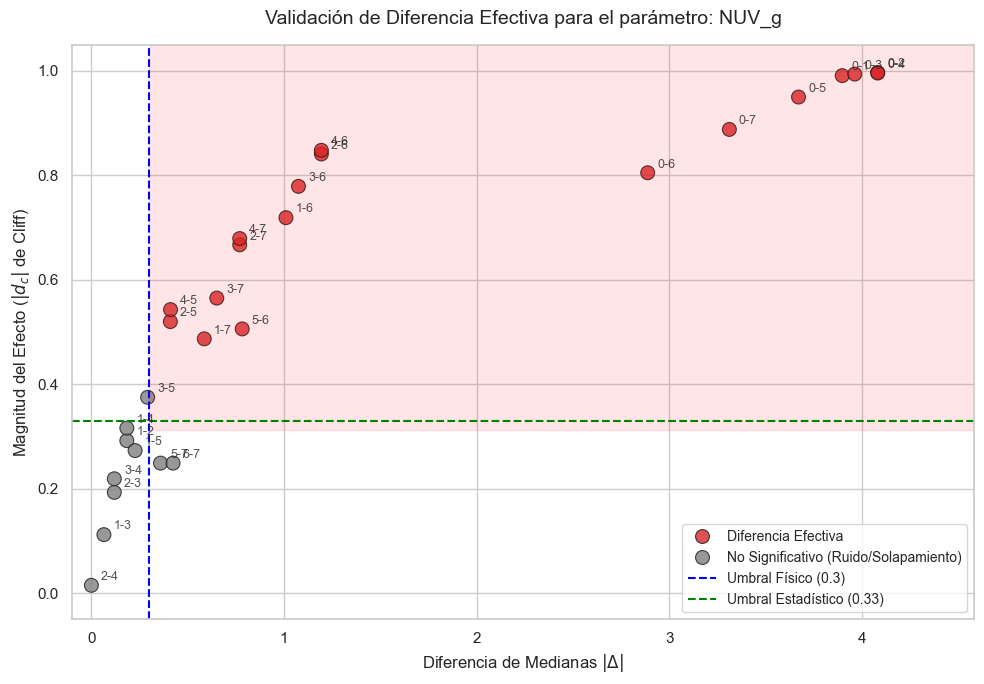

In [ ]:
def graficar_cuadrantes(feature, matriz_cliff, matriz_mediana, umbral_mediana=0.3, umbral_cliff=0.33):
    """
    Genera el gráfico de cuadrantes para validar la diferencia efectiva entre comunidades.
    """
    pares = []
    dif_medianas = []
    cliff_deltas = []
    
    # Extraer las comunidades respetando sus nombres originales
    communities = matriz_cliff.columns
    
    # Recolectar solo los pares únicos (combinaciones)
    for c1, c2 in combinations(communities, 2):
        pares.append(f"{c1}-{c2}")
        dif_medianas.append(matriz_mediana.loc[c1, c2])
        cliff_deltas.append(matriz_cliff.loc[c1, c2])
        
    # Crear un DataFrame limpio solo para graficar
    df_plot = pd.DataFrame({
        'Par': pares,
        'Dif_Mediana': dif_medianas,
        'Cliff_Delta': cliff_deltas
    })
    
    # Etiquetar los puntos según si caen en el cuadrante de "Diferencia Efectiva"
    condicion_efectiva = (df_plot['Dif_Mediana'] >= umbral_mediana) & (df_plot['Cliff_Delta'] >= umbral_cliff)
    df_plot['Estado'] = np.where(condicion_efectiva, 'Diferencia Efectiva', 'No Significativo (Ruido/Solapamiento)')
    
    # --- Configuración del Gráfico ---
    plt.figure(figsize=(10, 7))
    sns.set_theme(style="whitegrid")
    
    # Crear el scatter plot
    ax = sns.scatterplot(
        data=df_plot, 
        x='Dif_Mediana', 
        y='Cliff_Delta', 
        hue='Estado',
        palette={'Diferencia Efectiva': '#d62728', 'No Significativo (Ruido/Solapamiento)': '#7f7f7f'},
        s=100, # Tamaño de los puntos
        alpha=0.8,
        edgecolor='k'
    )
    
    # Dibujar las líneas de umbral (La Magia)
    plt.axvline(x=umbral_mediana, color='blue', linestyle='--', linewidth=1.5, label=f'Umbral Físico ({umbral_mediana})')
    plt.axhline(y=umbral_cliff, color='green', linestyle='--', linewidth=1.5, label=f'Umbral Estadístico ({umbral_cliff})')
    
    # Anotar cada punto con el nombre del par (ej: 0-3)
    # Se añade un pequeño offset para que el texto no tape el punto
    for i in range(df_plot.shape[0]):
        plt.text(
            df_plot['Dif_Mediana'].iloc[i] + 0.05, 
            df_plot['Cliff_Delta'].iloc[i] + 0.01, 
            df_plot['Par'].iloc[i], 
            fontsize=9,
            alpha=0.8
        )
    
    # Sombrear el cuadrante superior derecho (Zona Efectiva)
    ax.axvspan(umbral_mediana, max(dif_medianas) + 0.5, ymin=umbral_cliff/1.0, ymax=1, alpha=0.1, color='red')
    
    # Ajustes estéticos y etiquetas
    plt.title(f'Validación de Diferencia Efectiva para el parámetro: {feature}', fontsize=14, pad=15)
    plt.xlabel(r'Diferencia de Medianas $|\Delta|$', fontsize=12)
    plt.ylabel(r'Magnitud del Efecto ($|d_c|$ de Cliff)', fontsize=12)
    
    # Ajustar límites para que se vea limpio
    plt.xlim(-0.1, max(dif_medianas) + 0.5)
    plt.ylim(-0.05, 1.05)
    
    # Configurar leyenda
    plt.legend(loc='lower right', frameon=True, fontsize=10)
    plt.tight_layout()
    
    # Mostrar el gráfico
    plt.show()

# --- Cómo usarlo con tus diccionarios ---
# Asumiendo que tus diccionarios se llaman matrices_cliff y matrices_dif_mediana
graficar_cuadrantes('NUV_g', matrices_cliff['NUV_g'], matrices_dif_mediana['NUV_g'])

In [67]:
# Crear una carpeta para guardar los gráficos si no existe
os.makedirs("../results/figures/graficos_cuadrantes", exist_ok=True)

# Umbral estadístico fijo para Delta de Cliff (0.33 = efecto mediano, 0.47 = efecto grande)
UMBRAL_CLIFF = 0.33 

communities_list = sorted(df_all['community'].unique())
n_com = len(communities_list)

# Lista para guardar un resumen maestro de los resultados
resumen_pares_efectivos = []

for feature, cutoff_fisico in theoretical_cutoffs.items():
    print(f"Procesando {feature} (Umbral: {cutoff_fisico})...")
    
    # 2. Extracción segura de datos
    communities_data = {c: df_all[df_all['community'] == c][feature].dropna().values for c in communities_list}
    
    pares = []
    dif_medianas = []
    cliff_deltas = []
    
    # 3. Cálculo de métricas por pares
    for c1, c2 in combinations(communities_list, 2):
        g1 = communities_data[c1]
        g2 = communities_data[c2]
        n1, n2 = len(g1), len(g2)
        
        # Mann-Whitney U y Delta de Cliff
        u1 = stats.mannwhitneyu(g1, g2, alternative='two-sided').statistic
        d_cliff = np.abs((2 * u1 / (n1 * n2)) - 1)
        
        # Diferencia de medianas
        dif_med = np.abs(np.median(g1) - np.median(g2))
        
        pares.append(f"{c1}-{c2}")
        dif_medianas.append(dif_med)
        cliff_deltas.append(d_cliff)
        
        # Guardar en el resumen si cumple ambas condiciones
        if dif_med >= cutoff_fisico and d_cliff >= UMBRAL_CLIFF:
            resumen_pares_efectivos.append({
                'Caracteristica': feature,
                'Par': f"{c1}-{c2}",
                'Dif_Mediana': round(dif_med, 3),
                'Delta_Cliff': round(d_cliff, 3)
            })

    # 4. Preparar datos para el gráfico
    df_plot = pd.DataFrame({'Par': pares, 'Dif_Mediana': dif_medianas, 'Cliff_Delta': cliff_deltas})
    condicion = (df_plot['Dif_Mediana'] >= cutoff_fisico) & (df_plot['Cliff_Delta'] >= UMBRAL_CLIFF)
    df_plot['Estado'] = np.where(condicion, 'Diferencia Efectiva', 'No Significativo')
    
    # 5. Generar el Gráfico de Cuadrantes Dinámico
    plt.figure(figsize=(9, 6))
    sns.set_theme(style="whitegrid")
    
    ax = sns.scatterplot(
        data=df_plot, x='Dif_Mediana', y='Cliff_Delta', hue='Estado',
        palette={'Diferencia Efectiva': '#d62728', 'No Significativo': '#7f7f7f'},
        s=100, alpha=0.8, edgecolor='k'
    )
    
    # Líneas con el corte específico de este color
    plt.axvline(x=cutoff_fisico, color='blue', linestyle='--', label=f'Umbral Teórico ({cutoff_fisico})')
    plt.axhline(y=UMBRAL_CLIFF, color='green', linestyle='--', label=f'Efecto Mínimo ({UMBRAL_CLIFF})')
    
    # Anotaciones
    for i in range(df_plot.shape[0]):
        plt.text(df_plot['Dif_Mediana'].iloc[i] + (cutoff_fisico * 0.05), # Offset dinámico
                 df_plot['Cliff_Delta'].iloc[i] + 0.01, 
                 df_plot['Par'].iloc[i], fontsize=8, alpha=0.7)
    
    # Sombreado del cuadrante de interés
    max_x = max(df_plot['Dif_Mediana'].max(), cutoff_fisico * 2) + (cutoff_fisico * 0.5)
    ax.axvspan(cutoff_fisico, max_x, ymin=UMBRAL_CLIFF/1.05, ymax=1, alpha=0.1, color='red')
    
    plt.title(f'Validación Topológica: {feature}', fontsize=14)
    plt.xlabel(r'Diferencia de Medianas $|\Delta|$', fontsize=12)
    plt.ylabel(r'Magnitud del Efecto ($|d_c|$)', fontsize=12)
    plt.xlim(-0.02, max_x)
    plt.ylim(-0.05, 1.05)
    plt.legend(loc='lower right', frameon=True)
    plt.tight_layout()
    
    # Guardar automáticamente
    plt.savefig(f"../results/figures/graficos_cuadrantes/validacion_{feature}.pdf", dpi=300)
    plt.close() # Cierra la figura para no saturar la memoria

# 6. Generar el reporte final
df_resumen = pd.DataFrame(resumen_pares_efectivos)
print("\nAnálisis completado. Gráficos guardados en la carpeta 'graficos_cuadrantes'.")

Procesando u_g (Umbral: 0.1)...
Procesando g_r (Umbral: 0.1)...
Procesando r_i (Umbral: 0.1)...
Procesando i_z (Umbral: 0.1)...
Procesando FUV_NUV (Umbral: 0.25)...
Procesando j_h (Umbral: 0.15)...
Procesando h_k (Umbral: 0.15)...
Procesando W1_W2 (Umbral: 0.15)...
Procesando i_W1 (Umbral: 0.3)...
Procesando r_W2 (Umbral: 0.3)...
Procesando NUV_u (Umbral: 0.25)...
Procesando NUV_g (Umbral: 0.25)...

Análisis completado. Gráficos guardados en la carpeta 'graficos_cuadrantes'.


In [69]:
UMBRAL_CLIFF = 0.33
P_VAL_MAX = 0.05

In [ ]:
# Diccionario para guardar las matrices booleanas puras por si las necesitas después
matrices_supervivencia = {}

os.makedirs("../results/figures/matrices_supervivencia", exist_ok=True)

for feature, cutoff_fisico in theoretical_cutoffs.items():
    print(f"Generando Matriz de Supervivencia para {feature}...")
    
    mat_p = matrices_mwu_p[feature]
    mat_cliff = matrices_cliff[feature]
    mat_mediana = matrices_dif_mediana[feature]
    
    # 1. Crear la Matriz de Verdad (Operaciones lógicas elemento por elemento)
    condicion_p = mat_p < P_VAL_MAX
    condicion_cliff = mat_cliff >= UMBRAL_CLIFF
    condicion_mediana = mat_mediana >= cutoff_fisico
    
    # La celda es True SOLO si cumple las 3 condiciones
    matriz_booleana = condicion_p & condicion_cliff & condicion_mediana
    matrices_supervivencia[feature] = matriz_booleana
    
    # 2. Generar el Heatmap Filtrado
    plt.figure(figsize=(8, 6))
    sns.set_theme(style="white")
    
    # La "máscara" oculta las celdas donde la condición es False (usamos ~ para invertir el booleano)
    mascara = ~matriz_booleana
    
    # Pintamos el mapa de calor usando los valores de diferencia de mediana
    ax = sns.heatmap(
        mat_mediana, 
        mask=mascara, 
        annot=True,        # Muestra el número de la diferencia
        fmt=".2f",         # 2 decimales
        cmap="YlOrRd",     # Colores: de amarillo a rojo intenso
        cbar_kws={'label': f'Dif. Mediana (Solo ≥ {cutoff_fisico})'},
        linewidths=1,
        linecolor='white',
        square=True
    )
    
    # Pintar el fondo de gris claro para representar el "ruido/equivalencia"
    ax.set_facecolor('#E8E8E8')
    
    plt.title(f'Matriz de Supervivencia: {feature}\n(Filtro: p < 0.05, Cliff ≥ {UMBRAL_CLIFF}, Δ ≥ {cutoff_fisico})', pad=15)
    plt.ylabel('Comunidad')
    plt.xlabel('Comunidad')
    plt.tight_layout()
    
    # Guardar la figura
    plt.savefig(f"../results/figures/matrices_supervivencia/heatmap_supervivencia_{feature}.pdf", dpi=300)
    plt.close()

print("\n¡Matrices de supervivencia generadas con éxito!")

Generando Matriz de Supervivencia para u_g...
Generando Matriz de Supervivencia para g_r...
Generando Matriz de Supervivencia para r_i...
Generando Matriz de Supervivencia para i_z...
Generando Matriz de Supervivencia para FUV_NUV...
Generando Matriz de Supervivencia para j_h...
Generando Matriz de Supervivencia para h_k...
Generando Matriz de Supervivencia para W1_W2...
Generando Matriz de Supervivencia para i_W1...
Generando Matriz de Supervivencia para r_W2...
Generando Matriz de Supervivencia para NUV_u...
Generando Matriz de Supervivencia para NUV_g...

¡Matrices de supervivencia generadas con éxito!


In [73]:
# Supongamos que feature_base = 'i_W1'
feature_base = 'r_W2'
matriz_supervivencia_base = matrices_supervivencia[feature_base]
comunidades = matriz_supervivencia_base.columns

# 1. Crear un grafo vacío
G_oscurecimiento = nx.Graph()
G_oscurecimiento.add_nodes_from(comunidades)

# 2. Conectar las comunidades que son EQUIVALENTES (celda = False)
# Si son equivalentes en i_W1, comparten el mismo régimen de oscurecimiento
for i in range(len(comunidades)):
    for j in range(i + 1, len(comunidades)):
        c1 = comunidades[i]
        c2 = comunidades[j]
        
        # Si NO sobrevivió al filtro estricto, son equivalentes
        if not matriz_supervivencia_base.loc[c1, c2]:
            G_oscurecimiento.add_edge(c1, c2)

# 3. Extraer los Macro-Grupos (Componentes Conectados)
macro_grupos = list(nx.connected_components(G_oscurecimiento))

print(f"--- Análisis Jerárquico: Regímenes de Oscurecimiento ({feature_base}) ---")
for idx, grupo in enumerate(macro_grupos):
    # Para saber si el grupo es Oscurecido (Tipo 2) o Prístino (Tipo 1), 
    # calculamos la mediana global del grupo en la característica original.
    # Valores más altos de i_W1 o r_W2 indican más polvo/infrarrojo.
    
    datos_grupo = df_all[df_all['community'].isin(grupo)][feature_base].dropna()
    mediana_grupo = np.median(datos_grupo)
    
    print(f"Macro-Régimen {idx + 1}: Comunidades {sorted(list(grupo))}")
    print(f"  -> Mediana {feature_base}: {mediana_grupo:.3f}")

--- Análisis Jerárquico: Regímenes de Oscurecimiento (r_W2) ---
Macro-Régimen 1: Comunidades [0, np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(6), np.int64(7)]
  -> Mediana r_W2: 2.474
Macro-Régimen 2: Comunidades [5]
  -> Mediana r_W2: 1.894


In [74]:
feature_ir = 'W1_W2'
matriz_supervivencia_ir = matrices_supervivencia[feature_ir]
comunidades = matriz_supervivencia_ir.columns

# 1. Crear el grafo de Equivalencia Térmica
G_termico = nx.Graph()
G_termico.add_nodes_from(comunidades)

# 2. Conectar comunidades que NO superaron el umbral de Δ >= 0.15 y Cliff
for i in range(len(comunidades)):
    for j in range(i + 1, len(comunidades)):
        c1 = comunidades[i]
        c2 = comunidades[j]
        
        if not matriz_supervivencia_ir.loc[c1, c2]:
            G_termico.add_edge(c1, c2)

# 3. Extraer los Macro-Grupos Térmicos
macro_grupos_ir = list(nx.connected_components(G_termico))

print(f"--- Análisis Jerárquico: Régimen Térmico y Galaxia Anfitriona ({feature_ir}) ---")
for idx, grupo in enumerate(macro_grupos_ir):
    # Calculamos la mediana de W1_W2 para el grupo entero
    datos_grupo = df_all[df_all['community'].isin(grupo)][feature_ir].dropna()
    mediana_w1_w2 = np.median(datos_grupo)
    
    # Clasificación automática basada en Stern et al. 2012
    if mediana_w1_w2 >= 0.8:
        clasificacion = "AGN Puro (Dominado por Toroide)"
    else:
        clasificacion = "Contaminado (Dominado por Galaxia Anfitriona)"
        
    print(f"Sub-Régimen {idx + 1}: Comunidades {sorted(list(grupo))}")
    print(f"  -> Mediana {feature_ir}: {mediana_w1_w2:.3f} ---> {clasificacion}")

--- Análisis Jerárquico: Régimen Térmico y Galaxia Anfitriona (W1_W2) ---
Sub-Régimen 1: Comunidades [0, np.int64(1), np.int64(2), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
  -> Mediana W1_W2: 0.840 ---> AGN Puro (Dominado por Toroide)
Sub-Régimen 2: Comunidades [3]
  -> Mediana W1_W2: 0.490 ---> Contaminado (Dominado por Galaxia Anfitriona)


In [75]:
# Seleccionamos el cruce UV-Óptico
feature_uv = 'NUV_u' 
matriz_supervivencia_uv = matrices_supervivencia[feature_uv]
comunidades = matriz_supervivencia_uv.columns

# 1. Crear el grafo del Régimen Ultravioleta
G_uv = nx.Graph()
G_uv.add_nodes_from(comunidades)

# 2. Conectar comunidades equivalentes en el UV (las que NO superan Δ >= 0.25 y Cliff)
for i in range(len(comunidades)):
    for j in range(i + 1, len(comunidades)):
        c1 = comunidades[i]
        c2 = comunidades[j]
        
        if not matriz_supervivencia_uv.loc[c1, c2]:
            G_uv.add_edge(c1, c2)

# 3. Extraer los Macro-Grupos Ultravioleta
macro_grupos_uv = list(nx.connected_components(G_uv))

print(f"--- Análisis Jerárquico: Régimen Cinemático/Cosmológico ({feature_uv}) ---")
for idx, grupo in enumerate(macro_grupos_uv):
    datos_grupo = df_all[df_all['community'].isin(grupo)][feature_uv].dropna()
    mediana_uv = np.median(datos_grupo)
    
    print(f"Sub-Régimen UV {idx + 1}: Comunidades {sorted(list(grupo))}")
    print(f"  -> Mediana {feature_uv}: {mediana_uv:.3f}")

--- Análisis Jerárquico: Régimen Cinemático/Cosmológico (NUV_u) ---
Sub-Régimen UV 1: Comunidades [0]
  -> Mediana NUV_u: 4.245
Sub-Régimen UV 2: Comunidades [1, np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
  -> Mediana NUV_u: 0.343


In [76]:
# Elegimos un color del continuo óptico puro
feature_opt = 'g_r'
matriz_supervivencia_opt = matrices_supervivencia[feature_opt]
comunidades = matriz_supervivencia_opt.columns

# 1. Crear el grafo del Continuo Óptico
G_opt = nx.Graph()
G_opt.add_nodes_from(comunidades)

# 2. Conectar comunidades equivalentes (las que NO superan el umbral fino Δ >= 0.10 y Cliff)
for i in range(len(comunidades)):
    for j in range(i + 1, len(comunidades)):
        c1 = comunidades[i]
        c2 = comunidades[j]
        
        if not matriz_supervivencia_opt.loc[c1, c2]:
            G_opt.add_edge(c1, c2)

# 3. Extraer los Micro-Grupos del Disco
micro_grupos_opt = list(nx.connected_components(G_opt))

print(f"--- Análisis Jerárquico: Régimen del Disco de Acreción ({feature_opt}) ---")
for idx, grupo in enumerate(micro_grupos_opt):
    datos_grupo = df_all[df_all['community'].isin(grupo)][feature_opt].dropna()
    mediana_opt = np.median(datos_grupo)
    
    print(f"Micro-Régimen Óptico {idx + 1}: Comunidades {sorted(list(grupo))}")
    print(f"  -> Mediana {feature_opt}: {mediana_opt:.3f}")

--- Análisis Jerárquico: Régimen del Disco de Acreción (g_r) ---
Micro-Régimen Óptico 1: Comunidades [0, np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(7)]
  -> Mediana g_r: 0.343
Micro-Régimen Óptico 2: Comunidades [6]
  -> Mediana g_r: 0.573


In [82]:
# Definimos las bandas clave que gobiernan los 4 regímenes
bandas_diagnostico = ['i_W1', 'r_W2', 'W1_W2', 'FUV_NUV', 'NUV_u', 'NUV_g', 'g_r']

# Sacamos la mediana de cada banda por comunidad
df_medianas_comunidades = df_all.groupby('community')[bandas_diagnostico].median()

print("--- Medianas Exactas por Comunidad ---")
print(df_medianas_comunidades.round(3))

--- Medianas Exactas por Comunidad ---
            i_W1   r_W2  W1_W2  FUV_NUV  NUV_u  NUV_g    g_r
community                                                   
0          1.348  2.249  0.694    0.875  4.245  4.457  0.419
1          1.246  2.283  0.891    1.488  0.326  0.558  0.343
2          1.803  2.687  0.814    0.152  0.199  0.375  0.309
3          1.601  2.261  0.490    0.247  0.309  0.493  0.287
4          1.486  2.523  0.899    0.939  0.197  0.375  0.329
5          1.026  1.894  0.718    1.334  0.538  0.785  0.383
6          1.771  2.865  0.873    1.508  0.981  1.569  0.573
7          1.312  2.336  0.877    5.169  0.849  1.145  0.354


In [99]:
communities_list = sorted(df_all['community'].unique())
diagnosticos = []

# Definimos nuestra población de control (Cuásar Tipo 1 estándar)
# Basado en tus medianas, C1 es el ancla perfecta.
c_ref = 1 

for c in communities_list:
    datos_c = df_all[df_all['community'] == c]
    
    # Solo necesitamos las medianas para saber la dirección de la diferencia,
    # NO para decidir si son estadísticamente distintos.
    mediana_i_W1 = datos_c['i_W1'].median()
    mediana_W1_W2 = datos_c['W1_W2'].median()
    mediana_NUV_g = datos_c['NUV_g'].median()
    mediana_FUV_NUV = datos_c['FUV_NUV'].median()
    mediana_g_r = datos_c['g_r'].median()
    
    # --- Árbol de Decisión Activado por Estadística ---
    
    # 1. Filtro de Oscurecimiento (i_W1)
    es_distinto_i_W1 = matrices_supervivencia['i_W1'].loc[c, c_ref]
    if es_distinto_i_W1 and (mediana_i_W1 > df_all[df_all['community'] == c_ref]['i_W1'].median()):
        regimen_oscurecimiento = "Enrojecido/Oscurecido (Estadísticamente Significativo)"
    else:
        regimen_oscurecimiento = "Despejado (Equivalente a Control)"

    # 2. Filtro Térmico / Galaxia (W1_W2)
    es_distinto_W1_W2 = matrices_supervivencia['W1_W2'].loc[c, c_ref]
    if es_distinto_W1_W2 and (mediana_W1_W2 < df_all[df_all['community'] == c_ref]['W1_W2'].median()):
        dominio_termico = "Dominado por Galaxia (Seyfert)"
    else:
        dominio_termico = "Dominado por AGN (Equivalente a Control)"
        
    # 3. Filtro UV (NUV_g y FUV_NUV)
    es_distinto_NUV_g = matrices_supervivencia['NUV_g'].loc[c, c_ref]
    es_distinto_FUV_NUV = matrices_supervivencia['FUV_NUV'].loc[c, c_ref]
    
    if es_distinto_NUV_g and (mediana_NUV_g > 2.0): # Sabemos que C0 salta aquí
        anomalia_uv = "Dropout NUV (Absorción/z Extremo)"
    elif es_distinto_FUV_NUV and (mediana_FUV_NUV > 3.0): # Sabemos que C7 salta aquí
        anomalia_uv = "Dropout FUV (Absorción/z Fuerte)"
    else:
        anomalia_uv = "Continuo UV Normal"
        
    # 4. Filtro del Disco (g_r)
    es_distinto_g_r = matrices_supervivencia['g_r'].loc[c, c_ref]
    if es_distinto_g_r:
        if mediana_g_r > df_all[df_all['community'] == c_ref]['g_r'].median():
            estado_disco = "Disco Rojo"
        else:
            estado_disco = "Disco Azul"
    else:
        estado_disco = "Continuo Óptico Normal"

    # --- Síntesis Astrofísica ---
    # La etiqueta principal se define por la desviación estadística más extrema
    if "Dropout" in anomalia_uv:
        clasificacion = "Anomalía UV"
    elif dominio_termico == "Dominado por Galaxia (Seyfert)":
        clasificacion = "AGN Diluido por Galaxia"
    elif regimen_oscurecimiento == "Enrojecido/Oscurecido (Estadísticamente Significativo)":
        clasificacion = "AGN Enrojecido"
    else:
        clasificacion = "Cuásar Estándar"

    diagnosticos.append({
        'Comunidad': c,
        'Oscurecimiento (i-W1)': regimen_oscurecimiento,
        'Régimen Térmico (W1-W2)': dominio_termico,
        'Cinemática UV': anomalia_uv,
        'Disco (g-r)': estado_disco,
        'Clasificación Astrofísica': clasificacion
    })

df_diagnostica_rigurosa = pd.DataFrame(diagnosticos)
df_diagnostica_rigurosa

,Comunidad,Oscurecimiento (i-W1),Régimen Térmico (W1-W2),Cinemática UV,Disco (g-r),Clasificación Astrofísica
0,0,Despejado (Equivalente a Control),Dominado por Galaxia (Seyfert),Dropout NUV (Absorción/z Extremo),Continuo Óptico Normal,Anomalía UV
1,1,Despejado (Equivalente a Control),Dominado por AGN (Equivalente a Control),Continuo UV Normal,Continuo Óptico Normal,Cuásar Estándar
2,2,Enrojecido/Oscurecido (Estadísticamente Signif...,Dominado por AGN (Equivalente a Control),Continuo UV Normal,Continuo Óptico Normal,AGN Enrojecido
3,3,Enrojecido/Oscurecido (Estadísticamente Signif...,Dominado por Galaxia (Seyfert),Continuo UV Normal,Continuo Óptico Normal,AGN Diluido por Galaxia
4,4,Despejado (Equivalente a Control),Dominado por AGN (Equivalente a Control),Continuo UV Normal,Continuo Óptico Normal,Cuásar Estándar
5,5,Despejado (Equivalente a Control),Dominado por Galaxia (Seyfert),Continuo UV Normal,Continuo Óptico Normal,AGN Diluido por Galaxia
6,6,Enrojecido/Oscurecido (Estadísticamente Signif...,Dominado por AGN (Equivalente a Control),Continuo UV Normal,Disco Rojo,AGN Enrojecido
7,7,Despejado (Equivalente a Control),Dominado por AGN (Equivalente a Control),Dropout FUV (Absorción/z Fuerte),Continuo Óptico Normal,Anomalía UV
